SVM is a supervised machine learning algorithm used for classification and regression. It finds the best boundary (hyperplane) that separates different classes with the maximum possible margin.

In [21]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.svm import SVC # support vector classifier
from sklearn.metrics import classification_report ,confusion_matrix , accuracy_score
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV

              precision    recall  f1-score   support

           0       0.94      0.90      0.92       135
           1       0.88      0.93      0.91       115

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250

[[121  14]
 [  8 107]]
0.912
Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ......

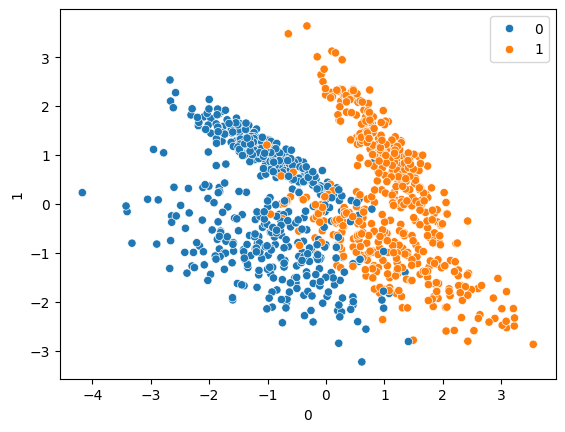

In [27]:
make_classification()
x,y=make_classification(n_samples=1000,n_classes=2,n_features=2,n_redundant=0,n_clusters_per_class=2)
# display(x)
# display(y)
sns.scatterplot(x=pd.DataFrame(x)[0],y=pd.DataFrame(x)[1],hue=y)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
x_train.shape
model=SVC(kernel='linear')
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

# Evaluation: 
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred,y_test))
print(accuracy_score(y_pred,y_test))

# Hyperparameter tuning: 
param_grid={
    'C':[0.1,0.5,1,4,8,10],
    'gamma':[1,0.1,0.2,0.001,0.002,0.003],
    'kernel':['linear']
}
grid_svc_model=GridSearchCV(estimator=SVC(),param_grid=param_grid,cv=5,verbose=2) # verbose print progress:-> 1: in short , 2: print all param, 5 in more details
grid_svc_model.fit(x_train,y_train)
y_grid_pred=grid_svc_model.predict(x_test)
acc_=accuracy_score(y_grid_pred,y_test)

In [28]:
print(f"best parameter{grid_svc_model.best_params_}")
print(classification_report(y_grid_pred,y_test))
print(f"accuracy under hyperparameter tuning {acc_}")

best parameter{'C': 0.5, 'gamma': 1, 'kernel': 'linear'}
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       135
           1       0.88      0.93      0.91       115

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250

accuracy under hyperparameter tuning 0.912
